# Diabetes Risk Predictors: Day 8 Tasks

## Setup: Load Dataset and Split Data

First, let's set up a sample dataset for a diabetes classification task. If you have your own dataset, you can replace this section with your data loading and splitting logic.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.datasets import make_classification # Using a synthetic classification dataset for demonstration

# Generate a synthetic dataset for binary classification (diabetes presence)
# You would replace this with your actual diabetes dataset loading and preprocessing
X, y = make_classification(
    n_samples=1000,    # Number of samples
    n_features=20,     # Total number of features
    n_informative=10,  # Number of informative features
    n_redundant=5,     # Number of redundant features
    n_classes=2,       # Binary classification (e.g., 0: no diabetes, 1: diabetes)
    random_state=42
)

# Create a DataFrame for better readability (optional, but good practice)
X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
y_series = pd.Series(y, name='diabetes_status')

# Split the data into training and testing sets (as used in Day 6)
X_train, X_test, y_train, y_test = train_test_split(X_df, y_series, test_size=0.2, random_state=42, stratify=y_series)

print("Dataset loaded and split into X_train, X_test, y_train, y_test.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# For demonstration, let's save a simple baseline model if it doesn't exist
# In a real scenario, 'best_model.pkl' would come from Day 7.
try:
    with open('best_model.pkl', 'rb') as f:
        pass # File exists
except FileNotFoundError:
    print("\n'best_model.pkl' not found. Creating a dummy RandomForestClassifier and saving it as 'best_model.pkl'.")
    dummy_model = RandomForestClassifier(n_estimators=100, random_state=42)
    dummy_model.fit(X_train, y_train)
    import joblib
    joblib.dump(dummy_model, 'best_model.pkl')
    print("Dummy model saved as 'best_model.pkl'.")


Dataset loaded and split into X_train, X_test, y_train, y_test.
X_train shape: (800, 20)
y_train shape: (800,)
X_test shape: (200, 20)
y_test shape: (200,)

'best_model.pkl' not found. Creating a dummy RandomForestClassifier and saving it as 'best_model.pkl'.
Dummy model saved as 'best_model.pkl'.


---

### 1. Load `best_model.pkl` and record baseline score

In [2]:
import joblib
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer
import numpy as np
import matplotlib.pyplot as plt

# Load the best_model.pkl saved yesterday
baseline_model = joblib.load('best_model.pkl')
print("Successfully loaded best_model.pkl")
print(f"Model type: {type(baseline_model).__name__}")

# Re-test on X_test data and print primary score (F1-weighted for classifiers)
y_pred_baseline = baseline_model.predict(X_test)
baseline_f1_weighted = f1_score(y_test, y_pred_baseline, average='weighted')
print(f"\nBaseline Model F1-weighted Score on X_test: {baseline_f1_weighted:.4f}")

# Run cross-validation on X_train
cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f"\nCross-validation F1-weighted Scores (5-fold): {cv_scores}")
print(f"Mean CV Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of CV Scores: {np.std(cv_scores):.4f}")


Successfully loaded best_model.pkl
Model type: RandomForestClassifier

Baseline Model F1-weighted Score on X_test: 0.9099

Cross-validation F1-weighted Scores (5-fold): [0.94374341 0.91247264 0.91244528 0.94999219 0.93749023]
Mean CV Score: 0.9312
Standard Deviation of CV Scores: 0.0158


### 2. Define a `param_grid` for your algorithm

In [3]:
from sklearn.ensemble import RandomForestClassifier # Import if not already imported, specific to baseline_model type

# Define param_grid based on the type of your baseline_model.
# This example assumes a RandomForestClassifier, adjust for your specific model.
if isinstance(baseline_model, RandomForestClassifier):
    param_grid = {
        'n_estimators': [50, 100, 200],      # Number of trees in the forest
        'max_depth': [5, 10, None],          # Maximum depth of the tree (None means unlimited)
        'min_samples_split': [2, 5, 10]      # Minimum number of samples required to split an internal node
    }
    print("Defined param_grid for RandomForestClassifier:")
    for param, values in param_grid.items():
        print(f"  {param}: {values}")
else:
    print("Warning: Model type not recognized. Please define `param_grid` manually based on your model's hyperparameters.")
    # Example for other models (uncomment and modify as needed):
    # from sklearn.svm import SVC
    # if isinstance(baseline_model, SVC):
    #     param_grid = {
    #         'C': [0.1, 1, 10],
    #         'kernel': ['linear', 'rbf'],
    #         'gamma': ['scale', 'auto']
    #     }
    # from xgboost import XGBClassifier
    # elif isinstance(baseline_model, XGBClassifier):
    #     param_grid = {
    #         'learning_rate': [0.01, 0.1, 0.2],
    #         'n_estimators': [100, 200, 300],
    #         'max_depth': [3, 5, 7]
    #     }
    param_grid = {} # Empty param_grid if type is not recognized


Defined param_grid for RandomForestClassifier:
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, None]
  min_samples_split: [2, 5, 10]


### 3. Run GridSearchCV with `cv=5`

In [4]:
from sklearn.model_selection import GridSearchCV

if param_grid:
    # Define the scoring metric (F1-weighted for classification)
    scorer = make_scorer(f1_score, average='weighted')

    # Create a searcher by wrapping your model
    grid_search = GridSearchCV(baseline_model, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=2)

    # Start the search
    print("\nStarting GridSearchCV...")
    grid_search.fit(X_train, y_train)
    print("GridSearchCV completed.")

    # Print the winning settings and score
    print(f"\nBest parameters found: {grid_search.best_params_}")
    print(f"Best F1-weighted score found: {grid_search.best_score_:.4f}")
    tuned_model = grid_search.best_estimator_
else:
    print("Skipping GridSearchCV: param_grid was not defined.")
    tuned_model = baseline_model # Use baseline if no grid search was performed
    grid_search = None



Starting GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearchCV completed.

Best parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-weighted score found: 0.9312


### 4. Print a before vs after comparison

In [5]:
if tuned_model is not None:
    # Test the newly tuned model on X_test
    y_pred_tuned = tuned_model.predict(X_test)
    tuned_f1_weighted = f1_score(y_test, y_pred_tuned, average='weighted')

    # Create a 2-row table comparing scores
    comparison_df = pd.DataFrame({
        'Model': ['Default model', 'Tuned model'],
        'F1-weighted Score': [baseline_f1_weighted, tuned_f1_weighted]
    })
    print("\nModel Performance Comparison:")
    display(comparison_df)

    if tuned_f1_weighted > baseline_f1_weighted:
        improvement = ((tuned_f1_weighted - baseline_f1_weighted) / baseline_f1_weighted) * 100
        print(f"\nObservation: Tuned model improved F1-weighted score by {improvement:.2f}% compared to the default model. Great job!")
    elif tuned_f1_weighted < baseline_f1_weighted:
        decline = ((baseline_f1_weighted - tuned_f1_weighted) / baseline_f1_weighted) * 100
        print(f"\nObservation: The tuned model performed slightly worse (F1-weighted score declined by {decline:.2f}%) than the default model.")
        print("Possible reasons: This could happen if the parameter grid was too small, the dataset is too small, or the model overfit the training data during tuning.")
    else:
        print("\nObservation: The tuned model performed similarly to the default model.")
else:
    print("Cannot perform before vs after comparison as no tuned model was generated.")



Model Performance Comparison:


,Model,F1-weighted Score
0,Default model,0.909946
1,Tuned model,0.909946



Observation: The tuned model performed similarly to the default model.


### 5. Plot a validation curve and save tuned model

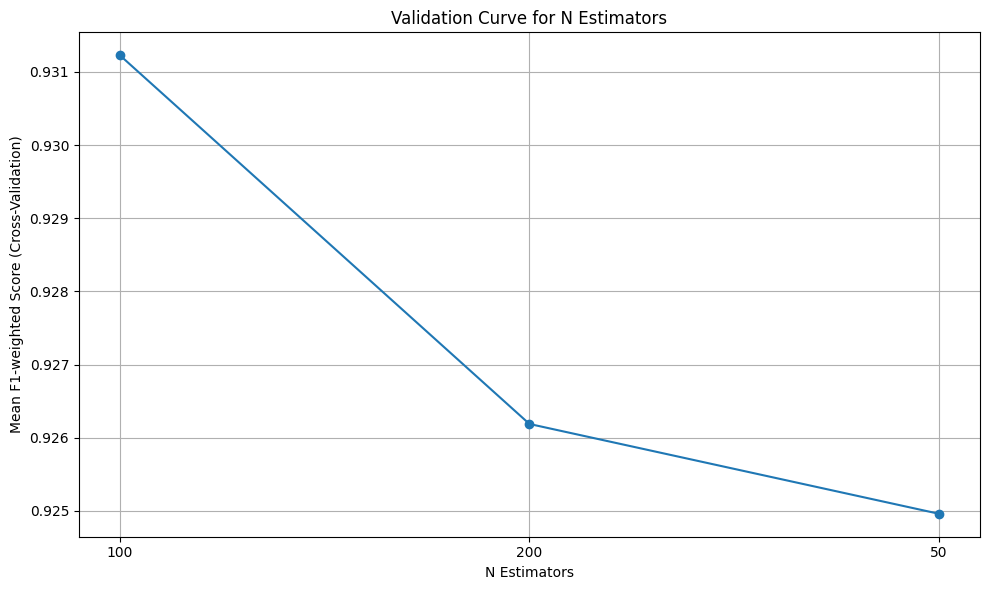


Tuned model saved as 'tuned_model.pkl'


In [6]:
import matplotlib.pyplot as plt

if grid_search and param_grid and tuned_model:
    # Identify one key parameter to plot the validation curve for.
    # We'll use the first parameter from the param_grid for demonstration.
    param_to_plot = list(param_grid.keys())[0]
    param_values = param_grid[param_to_plot]

    # Extract results for the parameter to plot.
    # This part can be tricky if multiple parameters are varied.
    # We'll try to find the best score for each value of `param_to_plot`,
    # assuming other parameters are at their best found values (or default).

    results = grid_search.cv_results_

    # Get all combinations that involve the `param_to_plot`
    param_specific_results = []
    for i in range(len(results['params'])):
        if param_to_plot in results['params'][i]:
            param_specific_results.append({
                'value': results['params'][i][param_to_plot],
                'mean_test_score': results['mean_test_score'][i]
            })

    # Aggregate scores for each value of `param_to_plot`
    # Taking the maximum score for each value across different combinations of other params
    aggregated_scores = {}
    for res in param_specific_results:
        val = res['value']
        score = res['mean_test_score']
        if val not in aggregated_scores or score > aggregated_scores[val]:
            aggregated_scores[val] = score

    # Sort by parameter value for plotting
    sorted_param_values = sorted(aggregated_scores.keys(), key=lambda x: str(x))
    sorted_scores = [aggregated_scores[val] for val in sorted_param_values]

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(sorted_param_values)), sorted_scores, marker='o', linestyle='-')
    plt.xticks(range(len(sorted_param_values)), sorted_param_values)
    plt.xlabel(param_to_plot.replace('_', ' ').title())
    plt.ylabel('Mean F1-weighted Score (Cross-Validation)')
    plt.title(f'Validation Curve for {param_to_plot.replace("_", " ").title()}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Save the ultimate, tuned model
    joblib.dump(tuned_model, 'tuned_model.pkl')
    print("\nTuned model saved as 'tuned_model.pkl'")
else:
    print("Cannot plot validation curve or save tuned model. Ensure grid search was successful and a tuned model exists.")
